In [5]:
# 3D linear advection: u1_t = - v1 u1_x - lambda1 u_1 + lambda2 p21 u2 + lambda3 p31 u3  
#                      u2_t = - v2 u2_x + lambda1 p12 u_1 - lambda2 u2 + lambda3 p32 u3  
#                      u3_t = - v3 u3_x + lambda1 p13 u_1 + lambda2 p23 u2 + lambda3 u3  
# We need at least one boundary condition as the derivative in x is degree 2
# but since we do not want to define the direction (sign) of a we set two
# PERIODIC BC
# 2 IC: u1(x,0)=a1*np.exp(-(x/sigma)**2) / np.sqrt((sigma**2)*np.pi)
#       u2(x,0)=a2*np.exp(-(x/sigma)**2) / np.sqrt((sigma**2)*np.pi)
#       u2(x,0)=a3*np.exp(-(x/sigma)**2) / np.sqrt((sigma**2)*np.pi)
#       with a3=1-a1-a2
# Spatial discretization: finite differences (upwind or central)
# Time integration: scipy.integrate.odeint

import numpy as np
import scipy
from scipy import integrate
from scipy.linalg import null_space
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import seaborn as sns
import pandas as pd

# initial condition function
def initial_condition(x, A, sigma):
    """Dirac delta approximated as a Gaussian with mean zero and variance (sigma^2)/2
    u(x,t) = (1/sqrt(2 pi)) * exp(-x^2 /sigma^2)"""
    u0 = np.outer(A, np.exp(-(x/sigma)**2) / np.sqrt((sigma**2)*np.pi)).flatten()
    return u0


# spatial derivatives
def upwind_derivative(u, dx, v):
    """First-order upwind derivative with periodic BC."""
    if v <= 0:
        return (np.roll(u, -1) - u) / dx       # (u_{i+1} - u_i) / dx
    else:
        return (u - np.roll(u, 1)) / dx         # (u_i - u_{i-1}) / dx


def build_rhs(n, V, Q, N, dx):
    """Return RHS function with periodic BC."""
    def rhs(u, t):
        U = u.reshape((n,N))
        vec = np.zeros((n,N))
        # compute rhs for each state
        # u1_t = - v1 u1_x - lambda1 u_1 + lambda2 p21 u2 + lambda3 p31 u3  
        # u2_t = - v2 u2_x + lambda1 p12 u_1 - lambda2 u2 + lambda3 p32 u3  
        # u3_t = - v3 u3_x + lambda1 p13 u_1 + lambda2 p23 u2 + lambda3 u3 
        
        for i in range(n):
            der = V[i]*upwind_derivative(U[i,:], dx, V[i])
            vec[i,:] += (- der + np.dot(Q[:,i],U))
        return vec.flatten()
    
    return rhs


# solver
def solve_one_state_advection(n, V, Q, A, L, T, N, nsteps, x, dx, t, dt, sigma):
    # Initial condition concatenation between [u10 u20]
    u0 = initial_condition(x, A, sigma)

    # RHS and time grid
    rhs = build_rhs(n, V, Q, N, dx)

    # Integrate ODE system
    def ODE(u, tt):
        return rhs(u, tt)

    u = scipy.integrate.odeint(ODE, u0, t)
    U = u.reshape((nsteps+1,n,N))

    return x, t, U

In [7]:
#set number of states
n = 3

#sigma for IC
sigma = 5

#set velocity
V = np.array([20, -15, 0])

#define lambdas
Lambda = np.array([1.0, 0.5, 0.3])

#define P
P = np.array([[0.0, 0.2, 0.8], [0.3, 0.0, 0.7], [0.7, 0.3, 0.0]])

#build Q
Q = np.zeros((n,n))
for i in range(n):
    for j in range(0,i):
        Q[i,j] = Lambda[i]*P[i,j]
    Q[i,i] = -Lambda[i]
    for j in range(i+1,n):
        Q[i,j] = Lambda[i]*P[i,j]

#set proportions A
#by computing w s.t. Q^T w = 0 and then P(st)=A
Qt = Q.T
W = null_space(Qt)
A = (W / np.sum(W)).flatten()
print('A =', A)

#set boundary of the domain
L = 80

#set time of simulation
T = 5

#number of cells in x grid
N = 2001

#build x grid
x = np.linspace(-L, L, N)

#delta x step
dx = x[1]-x[0] #=(2*L)/N

#obtain dt from the CFL condition
CFL = 0.9 # anything <=1
dt = CFL * dx / max(np.max(np.abs(V)), 1e-12)

nsteps = int(np.ceil(T / dt))
t = np.linspace(0.0, T, nsteps+1)

#time step
dt = T / nsteps

print("dx =", dx, " and dt =", dt)

x, t, UA = solve_one_state_advection(n, V, Q, A, L, T, N, nsteps, x, dx, t, dt, sigma)

A = [0.16446912 0.18320611 0.65232477]
dx = 0.0799999999999983  and dt = 0.003599712023038157


In [8]:
U = UA
colors = [['darkred','red'], ['darkblue','royalblue'], ['darkgreen','limegreen']]
totU = U[:,0,:] + U[:,1,:] + U[:,2,:]

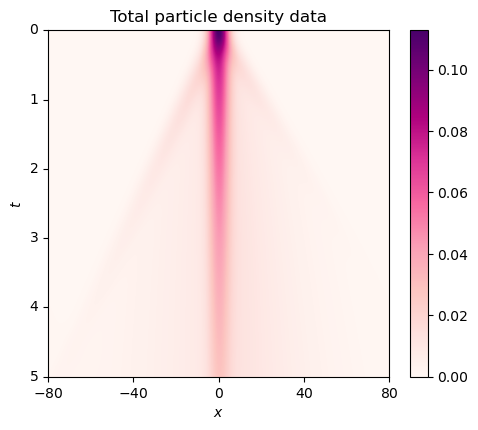

In [13]:
plt.figure(figsize=(5.5,4.5))

plt.gca().invert_yaxis()

xr = x
tr = t
Ur = totU

X, Y = np.meshgrid(xr,tr)

df = pd.DataFrame({
    "X": X.flatten(),
    "Y": Y.flatten(),
    "U": Ur.flatten()
})


heatmap_data = df.pivot(index="Y", columns="X", values="U")

ax = sns.heatmap(heatmap_data, annot=False, cmap="RdPu")


# values on x-axis
xtick_vals = [-80, -40, 0, 40, 80]

# find closest indices in xr
xtick_pos = [np.abs(xr - v).argmin() for v in xtick_vals]

ax.set_xticks(xtick_pos)
ax.set_xticklabels([r'$'+str(xtick_val)+'$' for xtick_val in xtick_vals], rotation=0)
ax.set_xlim([xtick_pos[0],xtick_pos[-1]])

# values on x-axis
ytick_vals = [0,1,2,3,4,5]

# find closest indices in tr
ytick_pos = [np.abs(tr - v).argmin() for v in ytick_vals]

ax.set_yticks(ytick_pos)
ax.set_yticklabels(ytick_vals)
ax.set_ylim([ytick_pos[-1],ytick_pos[0]])

plt.title('Total particle density data')
plt.xlabel('$x$')
plt.ylabel('$t$')

for spine in plt.gca().spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)

cbar = ax.collections[0].colorbar
cbar.outline.set_visible(True)
cbar.outline.set_linewidth(0.8)
    
plt.savefig("Figure_1B.png",
            format="png", bbox_inches="tight", dpi=600)

plt.show()